# MCC vs E-value Threshold
Compares **structure-based** vs **sequence-based** HMM across 2-fold cross-validation.

Files expected in `Data/Processed/`:
- `struct_set_1.class`, `struct_set_2.class`
- `seq_set_1.class`, `seq_set_2.class`

In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
import os

BASE = '../Data/Processed'

def parse_class(filepath):
    """Parse .class file: returns list of (label, evalue)"""
    data = []
    with open(filepath) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('#'):
                continue
            parts = line.split()
            if len(parts) < 3:
                continue
            label = int(parts[1])
            evalue = float(parts[2])
            data.append((label, evalue))
    return data

def confusion_at_threshold(data, t):
    TP = FP = TN = FN = 0
    for y, e in data:
        pred = 1 if e <= t else 0
        if pred == 1 and y == 1: TP += 1
        elif pred == 1 and y == 0: FP += 1
        elif pred == 0 and y == 0: TN += 1
        else: FN += 1
    return TP, FP, TN, FN

def mcc(TP, FP, TN, FN):
    num = TP*TN - FP*FN
    den = math.sqrt((TP+FP)*(TP+FN)*(TN+FP)*(TN+FN))
    return num/den if den != 0 else 0.0

# Load all 4 class files
struct1 = parse_class(f'{BASE}/struct_set_1.class')
struct2 = parse_class(f'{BASE}/struct_set_2.class')
seq1    = parse_class(f'{BASE}/seq_set_1.class')
seq2    = parse_class(f'{BASE}/seq_set_2.class')

print(f'struct_set_1: {len(struct1)} entries | pos={sum(y==1 for y,_ in struct1)} neg={sum(y==0 for y,_ in struct1)}')
print(f'struct_set_2: {len(struct2)} entries | pos={sum(y==1 for y,_ in struct2)} neg={sum(y==0 for y,_ in struct2)}')
print(f'seq_set_1:    {len(seq1)} entries | pos={sum(y==1 for y,_ in seq1)} neg={sum(y==0 for y,_ in seq1)}')
print(f'seq_set_2:    {len(seq2)} entries | pos={sum(y==1 for y,_ in seq2)} neg={sum(y==0 for y,_ in seq2)}')

struct_set_1: 287221 entries | pos=106 neg=287115
struct_set_2: 287219 entries | pos=105 neg=287114
seq_set_1:    287221 entries | pos=106 neg=287115
seq_set_2:    287219 entries | pos=105 neg=287114


In [3]:
THRESHOLDS = [1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8, 1e-9, 1e-10, 1e-11, 1e-12]

def mcc_curve(data):
    return [mcc(*confusion_at_threshold(data, t)) for t in THRESHOLDS]

mcc_struct1 = mcc_curve(struct1)
mcc_struct2 = mcc_curve(struct2)
mcc_seq1    = mcc_curve(seq1)
mcc_seq2    = mcc_curve(seq2)

print('Structure-based MCC (fold 1):', [round(m,4) for m in mcc_struct1])
print('Structure-based MCC (fold 2):', [round(m,4) for m in mcc_struct2])
print('Sequence-based MCC (fold 1): ', [round(m,4) for m in mcc_seq1])
print('Sequence-based MCC (fold 2): ', [round(m,4) for m in mcc_seq2])

Structure-based MCC (fold 1): [0.8549, 0.9478, 0.9768, 0.9859, 0.9953, 0.9905, 0.9905, 0.9905, 0.9905, 0.9809, 0.9809, 0.9761]
Structure-based MCC (fold 2): [0.8691, 0.9315, 0.9812, 0.9714, 0.9808, 0.9856, 0.9808, 0.9808, 0.9808, 0.971, 0.9661, 0.9611]
Sequence-based MCC (fold 1):  [0.8609, 0.9559, 0.9728, 0.9907, 0.9953, 0.9953, 0.9905, 0.9905, 0.9905, 0.9905, 0.9857, 0.9857]
Sequence-based MCC (fold 2):  [0.8754, 0.9265, 0.9721, 0.9761, 0.9808, 0.9856, 0.9808, 0.9808, 0.9808, 0.9759, 0.971, 0.9661]


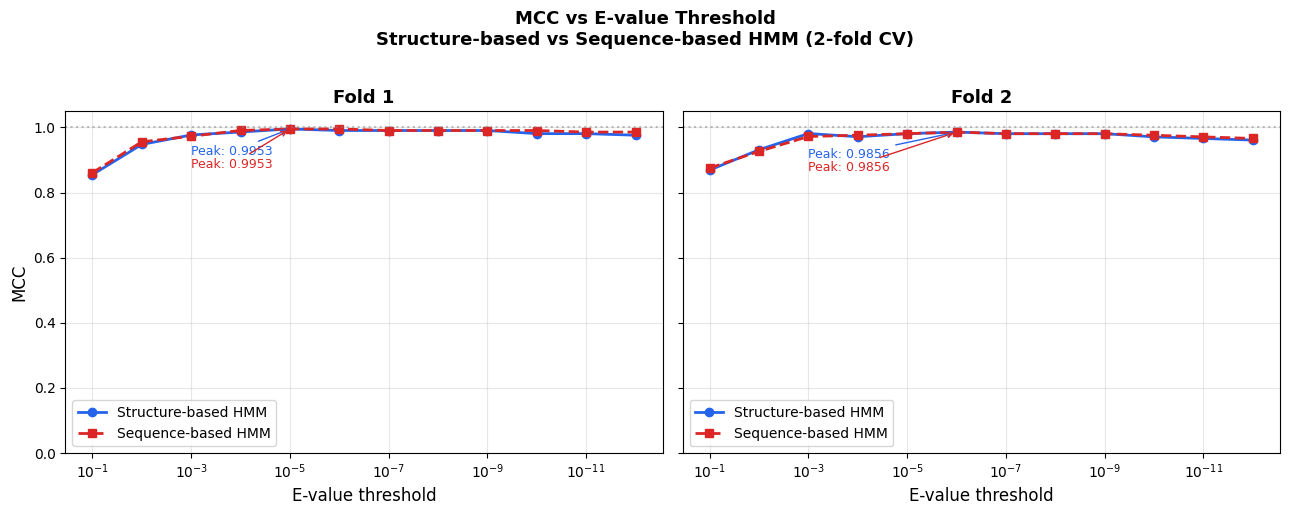

Saved: Figure_MCC_vs_Evalue.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

colors = {'struct': '#2563eb', 'seq': '#dc2626'}

# Left: Fold 1
axes[0].plot(THRESHOLDS, mcc_struct1, marker='o', color=colors['struct'],
             linewidth=2, markersize=6, label='Structure-based HMM')
axes[0].plot(THRESHOLDS, mcc_seq1, marker='s', color=colors['seq'],
             linewidth=2, markersize=6, linestyle='--', label='Sequence-based HMM')
axes[0].set_xscale('log')
axes[0].invert_xaxis()
axes[0].set_xlabel('E-value threshold', fontsize=12)
axes[0].set_ylabel('MCC', fontsize=12)
axes[0].set_title('Fold 1', fontsize=13, fontweight='bold')
axes[0].set_ylim(0, 1.05)
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=10)
axes[0].axhline(y=1.0, color='gray', linestyle=':', alpha=0.5)

# Annotate peak MCC for fold 1
peak_s1 = max(mcc_struct1)
peak_q1 = max(mcc_seq1)
axes[0].annotate(f'Peak: {peak_s1:.4f}', 
                 xy=(THRESHOLDS[mcc_struct1.index(peak_s1)], peak_s1),
                 xytext=(1e-3, peak_s1 - 0.08),
                 fontsize=9, color=colors['struct'],
                 arrowprops=dict(arrowstyle='->', color=colors['struct']))
axes[0].annotate(f'Peak: {peak_q1:.4f}', 
                 xy=(THRESHOLDS[mcc_seq1.index(peak_q1)], peak_q1),
                 xytext=(1e-3, peak_q1 - 0.12),
                 fontsize=9, color=colors['seq'],
                 arrowprops=dict(arrowstyle='->', color=colors['seq']))

# Right: Fold 2
axes[1].plot(THRESHOLDS, mcc_struct2, marker='o', color=colors['struct'],
             linewidth=2, markersize=6, label='Structure-based HMM')
axes[1].plot(THRESHOLDS, mcc_seq2, marker='s', color=colors['seq'],
             linewidth=2, markersize=6, linestyle='--', label='Sequence-based HMM')
axes[1].set_xscale('log')
axes[1].invert_xaxis()
axes[1].set_xlabel('E-value threshold', fontsize=12)
axes[1].set_title('Fold 2', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=10)
axes[1].axhline(y=1.0, color='gray', linestyle=':', alpha=0.5)

peak_s2 = max(mcc_struct2)
peak_q2 = max(mcc_seq2)
axes[1].annotate(f'Peak: {peak_s2:.4f}', 
                 xy=(THRESHOLDS[mcc_struct2.index(peak_s2)], peak_s2),
                 xytext=(1e-3, peak_s2 - 0.08),
                 fontsize=9, color=colors['struct'],
                 arrowprops=dict(arrowstyle='->', color=colors['struct']))
axes[1].annotate(f'Peak: {peak_q2:.4f}', 
                 xy=(THRESHOLDS[mcc_seq2.index(peak_q2)], peak_q2),
                 xytext=(1e-3, peak_q2 - 0.12),
                 fontsize=9, color=colors['seq'],
                 arrowprops=dict(arrowstyle='->', color=colors['seq']))

fig.suptitle('MCC vs E-value Threshold\nStructure-based vs Sequence-based HMM (2-fold CV)', 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('Figure_MCC_vs_Evalue.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: Figure_MCC_vs_Evalue.png')